In [2]:
#importing all libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [3]:
#loading csv file
df = pd.read_csv('zomato.csv')
df.head()

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet


In [4]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56252 entries, 0 to 56251
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   address                      56235 non-null  object
 1   name                         56236 non-null  object
 2   online_order                 56233 non-null  object
 3   book_table                   56194 non-null  object
 4   rate                         48414 non-null  object
 5   votes                        56174 non-null  object
 6   phone                        54956 non-null  object
 7   location                     56126 non-null  object
 8   rest_type                    55914 non-null  object
 9   dish_liked                   28027 non-null  object
 10  cuisines                     56049 non-null  object
 11  approx_cost(for two people)  55731 non-null  object
 12  listed_in(type)              51642 non-null  object
dtypes: object(13)
memory usage: 5.6

,0
address,17
name,16
online_order,19
book_table,58
rate,7838
votes,78
phone,1296
location,126
rest_type,338
dish_liked,28225


In [5]:
# Remove duplicates
df = df.drop_duplicates()

# Clean ratings
df['rate'] = df['rate'].astype(str).str.replace('/5', '')
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

# Clean cost column
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str).str.replace(',', '')
df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'], errors='coerce')

# Drop missing ratings
df = df.dropna(subset=['rate'])

In [7]:
#Top Rated Cuisines
df.groupby('cuisines')['rate'].mean().sort_values(ascending=False).head(10)

,rate
cuisines,
"Healthy Food, Salad, Mediterranean",4.900000
"Continental, North Indian, Italian, South Indian, Finger Food",4.900000
"Asian, Chinese, Thai, Momos",4.900000
"Asian, Mediterranean, North Indian, BBQ",4.800000
"North Indian, European, Mediterranean, BBQ",4.800000
"Continental, North Indian, Chinese, European, BBQ, Finger Food, Asian",4.800000
"European, Mediterranean, North Indian, BBQ",4.764286
"American, Tex-Mex, Burger, BBQ, Mexican",4.733333
"Continental, European, BBQ, Chinese, Asian",4.700000


In [8]:
#Top Locations
df['location'].value_counts().head(10)

,count
location,
BTM,2445
Koramangala 5th Block,1596
Indiranagar,1582
HSR,1562
Whitefield,1482
Marathahalli,1358
JP Nagar,1216
Jayanagar,1189
Bellandur,942


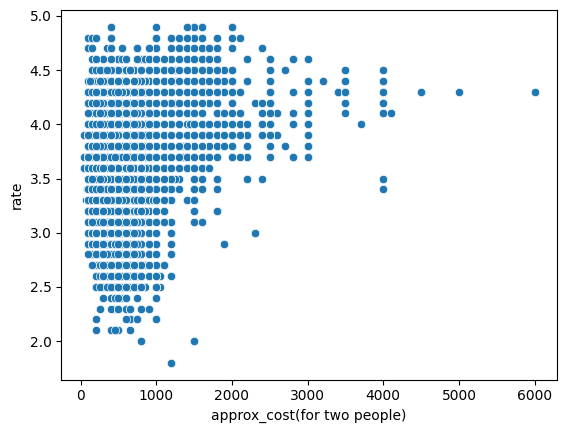

In [9]:
#Price vs Rating
sns.scatterplot(x='approx_cost(for two people)', y='rate', data=df)
plt.show()

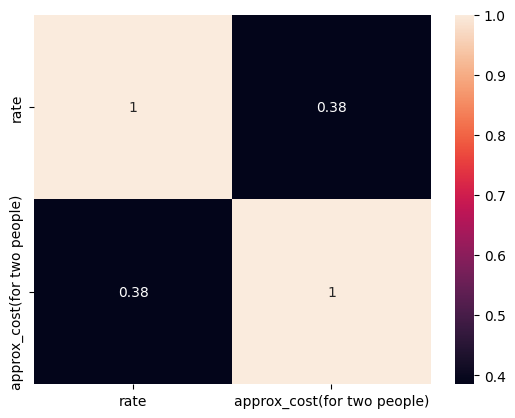

In [10]:
#Visualizations
#Heatmap
corr = df[['rate', 'approx_cost(for two people)']].corr()
sns.heatmap(corr, annot=True)
plt.show()

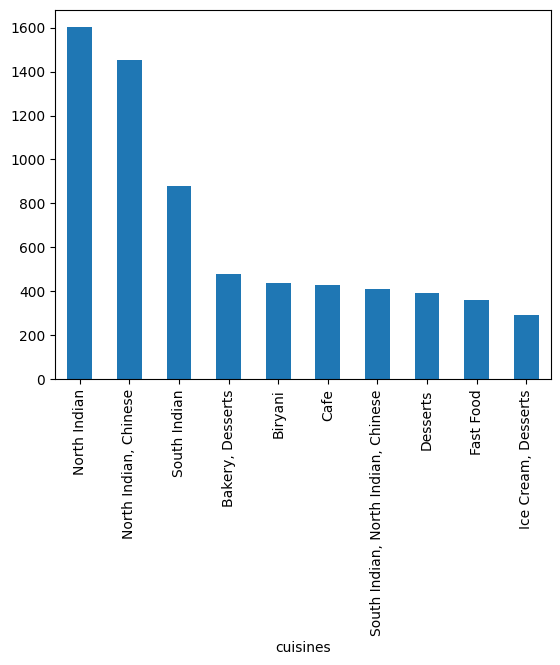

In [11]:
#Bar Chart
df['cuisines'].value_counts().head(10).plot(kind='bar')
plt.show()

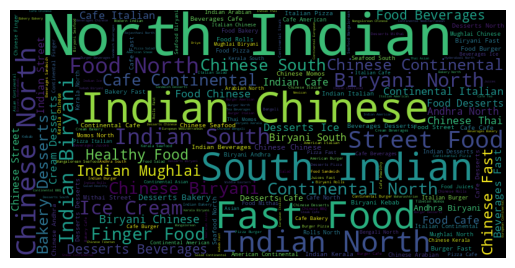

In [12]:
#WordCloud
text = " ".join(df['cuisines'].dropna())

wordcloud = WordCloud(width=800, height=400).generate(text)

plt.imshow(wordcloud)
plt.axis('off')
plt.show()

**Insights:**


**1.Most popular cuisines are:**

---
Healthy Food, Salad, Mediterranean
(4.900000)
    
Continental, North Indian, Italian, South Indian, Finger Food
(4.900000)

Asian, Chinese, Thai, Momos
(4.900000)
    
Asian, Mediterranean, North Indian, BBQ
(4.800000)
    
North Indian, European, Mediterranean, BBQ
(4.800000)

Continental, North Indian, Chinese, European, BBQ, Finger Food, Asian
(4.800000)    

European, Mediterranean, North Indian, BBQ
(4.764286)
    
American, Tex-Mex, Burger, BBQ, Mexican
(4.733333)
    
Continental, European, BBQ, Chinese, Asian
(4.700000)
    
Chinese, American, Continental, Italian, North Indian
(4.700000)

---



**2.Certain locations have more restaurants:**



---



BTM	2445

Koramangala 5th Block	1596

Indiranagar	1582

HSR	1562

Whitefield	1482

Marathahalli	1358

JP Nagar	1216

Jayanagar	1189

Bellandur	942

Bannerghatta Road

---



3.Ratings are not always dependent on price

---


4.Some low-cost restaurants have high ratings



**Recommendations**

* Focus on promoting high-rated and affordable restaurants to attract more customers.

* Partner with restaurants offering popular cuisines like North Indian, Chinese, and South Indian.

* Increase marketing efforts in high-density locations such as BTM, Koramangala, and Indiranagar.

* Highlight customer reviews and ratings to build trust and improve user decision-making.

* Provide visibility to underrated restaurants with good ratings to encourage fair competition.

---
